# 2.11 — Régression en grande dimension : ridge, PCR, PLS quand p dépasse n

**Navigation** : [<< 2.10-Optimisation-Hyperparametres](2.10-Optimisation-Hyperparametres.ipynb) | [2.13-Analyse-Erreurs >>](2.13-Analyse-Erreurs.ipynb) | [Index](../README.md)

**Kernel** : Python 3 · **Bibliothèque** : scikit-learn · **Niveau** : intermédiaire · **Durée** : ~45 min · **CPU** : < 5 min

***

En [2.3](2.3-Regression-lineaire-logistique.ipynb), la régression linéaire ajustait quelques coefficients sur nettement plus d'observations que de variables. Ce notebook installe le régime opposé, omniprésent en pratique — génomique (p ≈ 20 000 gènes, n ≈ 200 patients), spectroscopie infrarouge, texte, finance (autant de variables candidates que d'observations) : **p bien plus grand que n**. Dans ce régime les moindres carrés ordinaires cessent d'être un estimateur : le critère devient **non identifiable** — une infinité de solutions exactes — et le réflexe « réduire la dimension » hérité de [2.6](2.6-Clustering-KMeans-PCA.ipynb) demande une refondation : réduire la dimension **sur quel critère ?**

Le fil du notebook :

1. **Diagnostiquer** l'échec d'OLS en p >> n : rang déficient, infinité de solutions exactes, choix implicite du solveur ;
2. **Régulariser** avec le ridge : payer un peu de biais pour rendre le problème identifiable ;
3. **Régresser sur les composantes principales** (PCR) — l'ACP de [2.6](2.6-Clustering-KMeans-PCA.ipynb) réutilisée telle quelle comme régresseur ;
4. **Construire des composantes supervisées** avec la PLS (`sklearn.cross_decomposition.PLSRegression`) ;
5. **Choisir le nombre de composantes par validation croisée** (courbes RMSEP), pas par variance expliquée ;
6. **Comparer** ridge / PCR / PLS à protocole constant (mêmes folds, mêmes graines), avec un verdict par régime.

**Concept-phare** : **la variance n'est pas la prédictivité** — la direction de `X` qui porte le plus de variance peut être la moins utile pour prédire `y`. L'ACP (non supervisée) maximise `Var(Xu)` ; la PLS cherche des directions qui regardent `Cov(y, Xu)`. Toute la différence entre PCR et PLS tient dans cette paire de quantités.

### Prérequis

- [2.3](2.3-Regression-lineaire-logistique.ipynb) — moindres carrés, colinéarité ;
- [2.5](2.5-Biais-Variance-CV-ROC.ipynb) — compromis biais-variance, validation croisée ;
- [2.6](2.6-Clustering-KMeans-PCA.ipynb) — ACP, variance expliquée, choix du nombre de composantes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error

np.random.seed(42)
plt.rcParams["figure.dpi"] = 110

N_TRAIN, N_TEST = 60, 300                                   # n << p : c'est tout le sujet
BLOCS = [90, 45, 25, 14, 10, 6, 5, 5]                       # tailles des blocs (somme = p)
VARIANCES_F = np.array([3.0, 2.5, 2.0, 1.5, 1.2, 1.0, 1.0, 1.0])
SIGMA_X = 0.7                                               # bruit de mesure sur chaque variable
FACTEURS_SIGNAL = (6, 7)                                    # le signal vit sur les 2 derniers facteurs
P, L = sum(BLOCS), len(BLOCS)

print(f"n_train = {N_TRAIN}, n_test = {N_TEST}, p = {P}  ->  p/n = {P / N_TRAIN:.1f}")
print(f"{L} facteurs latents, blocs de variables de tailles {BLOCS}")
print(f"signal de y porté par les facteurs {list(FACTEURS_SIGNAL)} (blocs de {BLOCS[6]} et {BLOCS[7]} variables)")

n_train = 60, n_test = 300, p = 200  ->  p/n = 3.3
8 facteurs latents, blocs de variables de tailles [90, 45, 25, 14, 10, 6, 5, 5]
signal de y porté par les facteurs [6, 7] (blocs de 5 et 5 variables)


## 1. Le régime p >> n : pourquoi OLS échoue

Les moindres carrés ordinaires résolvent `min ||y - Xβ||²`. Quand `n < p`, le système `Xβ = y` est **sous-déterminé** : l'ensemble des solutions exactes est un espace affine de dimension `p - rang(X) ≥ p - n`. Le critère des moindres carrés ne **choisit** plus rien — nous allons le démontrer avec deux solutions exactes distinctes, indiscernables sur le train, radicalement différentes en test. Les solveurs (`numpy.linalg.lstsq`, scikit-learn) retournent en silence la solution de **norme minimale** : un choix implicite, rarement annoncé, dont il faut connaître l'existence.

### 1.1 Un générateur à facteurs latents contrôlé

Pour que les diagnostics soient lisibles, nous travaillons sur des données **synthétiques à vérité générative connue** : `X` est produite par `L = 8` facteurs latents indépendants (des « programmes » cachés), chaque facteur chargeant uniquement sur **son bloc** de variables (90, 45, 25, … variables) ; s'ajoute un bruit de mesure sur chaque variable. C'est le schéma des données génomiques — des blocs de gènes co-exprimés, portés par des régulateurs — ou spectroscopiques. Le signal de `y` est porté par les **deux derniers** facteurs : ceux qui n'expliquent presque rien de la variance de `X`.

In [2]:
def generer_donnees(n, rng, facteurs_signal=FACTEURS_SIGNAL, sigma_bruit_y=0.5):
    """Modèle à facteurs : X = Z @ W + bruit de mesure, y = 2.5 * (facteurs signal) + bruit.

    Z (n x L) : facteurs latents indépendants, variances VARIANCES_F.
    W (L x P) : le facteur l charge uniquement sur son bloc de variables.
    Par défaut le signal de y ne passe QUE par les facteurs 7 et 8 (5 variables chacun).
    """
    Z = rng.normal(size=(n, L)) * np.sqrt(VARIANCES_F)
    W = np.zeros((L, P))
    bornes = np.cumsum([0] + BLOCS)
    for l in range(L):
        W[l, bornes[l]:bornes[l + 1]] = 1.0
    X = Z @ W + rng.normal(scale=SIGMA_X, size=(n, P))
    y = sum(2.5 * Z[:, f] for f in facteurs_signal) + rng.normal(scale=sigma_bruit_y, size=n)
    return X, y, Z

rng = np.random.default_rng(42)
X_train, y_train, Z_train = generer_donnees(N_TRAIN, rng)
X_test, y_test, Z_test = generer_donnees(N_TEST, rng)

print("X_train :", X_train.shape, "| X_test :", X_test.shape)
c_intra = np.corrcoef(X_train[:, 0], X_train[:, 1])[0, 1]
c_inter = np.corrcoef(X_train[:, 0], X_train[:, 150])[0, 1]
print(f"corr(X[:,0], X[:,1])   intra-bloc 1 : {c_intra:+.2f}")
print(f"corr(X[:,0], X[:,150]) inter-blocs  : {c_inter:+.2f}")
print(f"std(y) sur train : {y_train.std():.2f}  (bruit irréductible : 0.50)")

# Standardisation ajustée sur le train uniquement (cf. 2.5 : jamais de fuite de test).
scaler = StandardScaler().fit(X_train)
Xs_train, Xs_test = scaler.transform(X_train), scaler.transform(X_test)

X_train : (60, 200) | X_test : (300, 200)
corr(X[:,0], X[:,1])   intra-bloc 1 : +0.84
corr(X[:,0], X[:,150]) inter-blocs  : +0.04
std(y) sur train : 3.58  (bruit irréductible : 0.50)


### 1.2 Ce que voit l'ACP : la variance, rien que la variance

Avant tout modèle, appliquons l'ACP de [2.6](2.6-Clustering-KMeans-PCA.ipynb) à `X_train`. Elle ordonne les directions par **variance expliquée** — c'est sa définition, et elle ne connaît pas `y`.

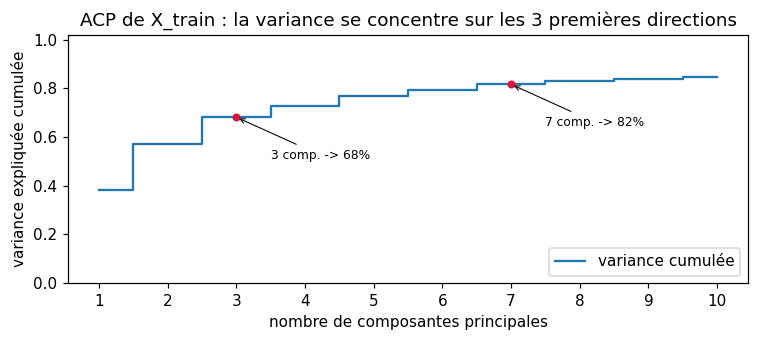

PC | part de variance | variance cumulée | |corr(y, score)|
PC 1 |      0.384       |      0.384      |     0.04
PC 2 |      0.186       |      0.570      |     0.04
PC 3 |      0.111       |      0.681      |     0.21
PC 4 |      0.046       |      0.727      |     0.09
PC 5 |      0.040       |      0.767      |     0.13
PC 6 |      0.028       |      0.795      |     0.33
PC 7 |      0.021       |      0.816      |     0.85
PC 8 |      0.015       |      0.831      |     0.16
PC 9 |      0.007       |      0.838      |     0.04
PC10 |      0.007       |      0.845      |     0.10


In [3]:
pca = PCA(random_state=42).fit(Xs_train)
var_expl = pca.explained_variance_ratio_
cumul = np.cumsum(var_expl)
T_pca = pca.transform(Xs_train)
cor_pcs = [abs(np.corrcoef(T_pca[:, j], y_train)[0, 1]) for j in range(10)]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.step(range(1, 11), cumul[:10], where="mid", label="variance cumulée")
for k in (3, 7):
    ax.scatter([k], [cumul[k - 1]], color="crimson", zorder=3, s=18)
    ax.annotate(f"{k} comp. -> {cumul[k - 1]:.0%}", (k, cumul[k - 1]),
                xytext=(k + 0.5, cumul[k - 1] - 0.17), fontsize=8,
                arrowprops=dict(arrowstyle="->", lw=0.7))
ax.set(xlabel="nombre de composantes principales", ylabel="variance expliquée cumulée",
       title="ACP de X_train : la variance se concentre sur les 3 premières directions", xticks=range(1, 11))
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print("PC | part de variance | variance cumulée | |corr(y, score)|")
for j in range(10):
    print(f"PC{j + 1:2d} |      {var_expl[j]:.3f}       |      {cumul[j]:.3f}      |     {cor_pcs[j]:.2f}")

Lecture du tableau — le concept-phare en une colonne : les **3 premières composantes** concentrent la variance (≈ 68 % cumulés), et leur corrélation avec `y` est quasi nulle. La composante qui porte le signal (`|corr| ≈ 0.85`) se trouve plus bas, avec ~2 % de variance. Si l'on choisissait le nombre de composantes au critère de variance de [2.6](2.6-Clustering-KMeans-PCA.ipynb) (seuil 90 % ou coude), on garderait les directions **dominantes en X mais muettes pour y** et on jetterait le signal. Ce n'est pas un défaut de l'ACP : c'est un défaut du **critère de sélection** quand l'objectif change — compresser `X` n'est pas prédire `y`. La section 3 y revient avec la validation croisée.

### 1.3 OLS : le diagnostic de l'échec

In [4]:
ols = LinearRegression().fit(Xs_train, y_train)
rmse_ols_train = root_mean_squared_error(y_train, ols.predict(Xs_train))
rmse_ols_test = root_mean_squared_error(y_test, ols.predict(Xs_test))

# Deuxième solution EXACTE des moindres carrés : beta_min-norm + 3*u, u dans le noyau de X.
rng_n = np.random.default_rng(7)
u = rng_n.normal(size=P)
u -= Xs_train.T @ np.linalg.pinv(Xs_train.T) @ u      # projection sur ker(X_train)
u /= np.linalg.norm(u)
beta2 = ols.coef_ + 3.0 * u
pred2_train = Xs_train @ beta2 + ols.intercept_
pred2_test = Xs_test @ beta2 + ols.intercept_

print(f"rang(X_train)              : {np.linalg.matrix_rank(Xs_train)}  (sur {P} colonnes)")
print(f"dimension de ker(X_train)  : {P - np.linalg.matrix_rank(Xs_train)}")
print(f"conditionnement de X       : {np.linalg.cond(Xs_train):.1e}")
print(f"||X @ u|| (u dans le noyau): {np.linalg.norm(Xs_train @ u):.1e}  <- u invisible sur le train")
print(f"RMSE train  solution 1 (min-norm) : {rmse_ols_train:.4f}")
print(f"RMSE train  solution 2 (+3u)      : {root_mean_squared_error(y_train, pred2_train):.4f}   <- identique : le critère ne les départage pas")
print(f"RMSE test   solution 1            : {rmse_ols_test:.3f}")
print(f"RMSE test   solution 2            : {root_mean_squared_error(y_test, pred2_test):.3f}   <- radicalement différente")

rang(X_train)              : 59  (sur 200 colonnes)
dimension de ker(X_train)  : 141
conditionnement de X       : 1.5e+16
||X @ u|| (u dans le noyau): 7.4e-14  <- u invisible sur le train
RMSE train  solution 1 (min-norm) : 0.0000
RMSE train  solution 2 (+3u)      : 0.0000   <- identique : le critère ne les départage pas
RMSE test   solution 1            : 1.541
RMSE test   solution 2            : 2.125   <- radicalement différente


L'échec d'OLS n'est pas « un mauvais RMSE » : c'est une **non-identification**. Les deux solutions ajustent le train **exactement aussi bien** (RMSE 0.0000), pourtant leurs prédictions en test divergent — le critère des moindres carrés est **aveugle** à cette différence. `LinearRegression` a fait un choix sans nous le dire : la solution de norme minimale (`lstsq`). Ce choix implicite n'est ni le vôtre ni celui des données ; il tombe « bien » ici (section 6 : min-norm est le plus mauvais des quatre modèles en moyenne, mais pas catastrophique), il peut tomber très mal selon le régime — la solution 2 ci-dessus en est une preuve constructive.

Face à ce diagnostic, deux stratégies : **contraindre les coefficients** (ridge, section 2) ou **régresser dans un sous-espace de petite dimension** (PCR et PLS, sections 3-4).

### Exercice 1 : quand n rattrape p

OLS n'est pas « cassée » dans l'absolu : le critère devient identifiable dès que `n` dépasse `p`. Vérifiez-le.

- **Objectif** : montrer que le RMSE test d'OLS décroît sérieusement dès que `n` franchit `p = 200`.
- **Etape 1** : pour chaque `n` de `[20, 40, 80, 160, 320, 640]`, générer un train de taille `n` et un test de 300 observations avec `generer_donnees` (fixer `rng_ex = np.random.default_rng(101)` **avant** la boucle).
- **Etape 2** : standardiser avec un scaler ajusté **sur le train de chaque itération**, ajuster `LinearRegression`, mesurer le RMSE test.
- **Indice** : au-delà de `n = p`, la solution devient unique ; le RMSE plafonne vers le plancher informationnel (≈ 0.5, le bruit de `y`).

In [5]:
# Exercice 1 — quand n rattrape p
# TODO etudiant : remplir la boucle et le dictionnaire resultats_ex1
tailles_ex1 = [20, 40, 80, 160, 320, 640]
resultats_ex1 = None   # TODO etudiant : dict {n: rmse_test}, standardisation par itération

print("Exercice 1 a completer : RMSE test d'OLS en fonction de n")

Exercice 1 a completer : RMSE test d'OLS en fonction de n


## 2. Ridge : payer un peu de biais pour rendre le problème identifiable

Le ridge d'Hoerl & Kennard (1970) remplace `min ||y - Xβ||²` par `min ||y - Xβ||² + α||β||²`. Le terme de pénalité rend la solution **unique pour tout α > 0** — le problème redevient bien posé, et l'infinité de solutions de la section 1.3 se réduisent à une seule — au prix d'un biais volontaire : c'est le compromis biais-variance de [2.5](2.5-Biais-Variance-CV-ROC.ipynb) appliqué au vecteur de coefficients. Le paramètre `α` est choisi par validation croisée, sur **les mêmes folds** pour toutes les méthodes de ce notebook — la comparaison finale (section 6) n'a de sens qu'à protocole constant.

In [6]:
FOLDS = KFold(n_splits=5, shuffle=True, random_state=42)

def rmsep_cv(modele, X, y):
    """RMSEP (RMSE de prédiction) en validation croisée 5-fold.

    Mêmes folds pour tous les modèles de ce notebook -> comparaison honnête.
    """
    erreurs = []
    for itr, ite in FOLDS.split(X):
        m = clone(modele)
        m.fit(X[itr], y[itr])
        pred = np.asarray(m.predict(X[ite])).ravel()
        erreurs.append(root_mean_squared_error(y[ite], pred))
    return np.array(erreurs)

print("5 folds de", [len(ite) for _, ite in FOLDS.split(Xs_train)][0], "observations chacun (shuffle, seed 42)")

5 folds de 12 observations chacun (shuffle, seed 42)


In [7]:
ALPHAS = np.logspace(-1, 4, 22)
rmse_cv_alpha = np.array([rmsep_cv(Ridge(alpha=a), Xs_train, y_train).mean() for a in ALPHAS])
best_alpha = ALPHAS[np.argmin(rmse_cv_alpha)]

ridge = Ridge(alpha=best_alpha).fit(Xs_train, y_train)
rmse_ridge_test = root_mean_squared_error(y_test, ridge.predict(Xs_test))

print(f"meilleur alpha (CV)    : {best_alpha:.1f}")
print(f"RMSEP CV au meilleur α : {rmse_cv_alpha.min():.3f}   (α=0.1 : {rmse_cv_alpha[0]:.3f}, α=1e4 : {rmse_cv_alpha[-1]:.3f})")
print(f"RMSE test ridge        : {rmse_ridge_test:.3f}   (OLS min-norm : {rmse_ols_test:.3f})")
print(f"||beta|| ridge         : {np.linalg.norm(ridge.coef_):.1f}   (OLS : {np.linalg.norm(ols.coef_):.1f})")

meilleur alpha (CV)    : 13.9
RMSEP CV au meilleur α : 1.526   (α=0.1 : 1.594, α=1e4 : 3.576)
RMSE test ridge        : 1.483   (OLS min-norm : 1.541)
||beta|| ridge         : 1.8   (OLS : 2.2)


La validation croisée choisit un **α intérieur** (ni 0 ni ∞) : trop petit, le ridge laisse vivre la non-identifiabilité de la section 1.3 ; trop grand, il écrase tous les coefficients vers la moyenne. C'est la courbe en U du compromis biais-variance — l'exercice 2 la trace. Le gain de RMSE test sur la solution min-norm est ici réel mais **modéré** : la vraie contribution du ridge sur ce jeu de données est la **stabilité** (une solution unique, des coefficients d'amplitude maîtrisée), pas un effondrement du RMSE. C'est exactement son rôle dans le pipeline QuantConnect de la série, où des centaines de features financières corrélées entrent dans une régression pénalisée : on ne cherche pas à identifier les variables, seulement à prédire de façon stable.

### Exercice 2 : la courbe en U du ridge

- **Objectif** : visualiser le compromis biais-variance du ridge comme une courbe en U.
- **Etape 1** : sur `grille_alpha = np.logspace(-3, 6, 37)`, calculer le RMSEP CV (moyenne des folds) pour chaque `α` avec `rmsep_cv`.
- **Etape 2** : tracer RMSEP vs `α` en axe x logarithmique, marquer le minimum. À gauche (α → 0) on retombe sur OLS ; à droite (α → ∞) le modèle prédit la moyenne.
- **Indice** : ajoutez une ligne horizontale au niveau du plancher informationnel (0.5) — le minimum ne descend jamais en dessous.

In [8]:
# Exercice 2 — la courbe en U du ridge
# TODO etudiant : calculer rmse_par_alpha puis tracer la courbe en U (axe x log)
grille_alpha = np.logspace(-3, 6, 37)
resultats_ex2 = None   # TODO etudiant : array des RMSEP CV sur grille_alpha

print("Exercice 2 a completer : courbe RMSEP vs alpha")

Exercice 2 a completer : courbe RMSEP vs alpha


## 3. PCR : régresser sur les composantes principales

La **PCR** (Principal Component Regression) réutilise l'ACP de [2.6](2.6-Clustering-KMeans-PCA.ipynb) **telle quelle** : on projette `X` sur ses `k` premières composantes principales, puis on régresse `y` sur les scores. Le sous-espace de dimension `k` est choisi **avant** de regarder `y` — c'est une réduction non supervisée. On n'implémente rien : `make_pipeline(PCA(n_components=k), LinearRegression())`.

Toute la question est le choix de `k`. La section 1.2 a montré que le critère de variance est trompeur ; le **critère prédictif** (validation croisée sur le RMSEP) tranche.

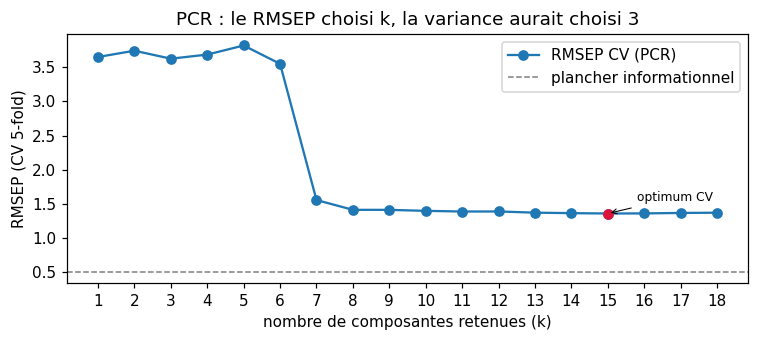

meilleur k (CV) : 15 composantes   (critère variance : 3 composantes suffisent à 68%)
RMSEP CV        : 1.356   (à k=3 : 3.628)
RMSE test PCR   : 1.356
variance portée par les k=15 composantes retenues : 87.6%


In [9]:
KS = list(range(1, 19))
rmse_cv_pcr = np.array([
    rmsep_cv(make_pipeline(PCA(n_components=k, random_state=42), LinearRegression()), Xs_train, y_train).mean()
    for k in KS
])
best_k_pcr = KS[np.argmin(rmse_cv_pcr)]

pcr = make_pipeline(PCA(n_components=best_k_pcr, random_state=42), LinearRegression()).fit(Xs_train, y_train)
rmse_pcr_test = root_mean_squared_error(y_test, pcr.predict(Xs_test))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(KS, rmse_cv_pcr, "o-", label="RMSEP CV (PCR)")
ax.scatter([best_k_pcr], [rmse_cv_pcr.min()], color="crimson", zorder=3)
ax.annotate("optimum CV", (best_k_pcr, rmse_cv_pcr.min()), xytext=(best_k_pcr + 0.8, rmse_cv_pcr.min() + 0.18),
            fontsize=8, arrowprops=dict(arrowstyle="->", lw=0.7))
ax.axhline(0.5, color="gray", ls="--", lw=1, label="plancher informationnel")
ax.set(xlabel="nombre de composantes retenues (k)", ylabel="RMSEP (CV 5-fold)",
       title="PCR : le RMSEP choisi k, la variance aurait choisi 3", xticks=KS)
ax.legend()
plt.tight_layout(); plt.show()

print(f"meilleur k (CV) : {best_k_pcr} composantes   (critère variance : 3 composantes suffisent à {cumul[2]:.0%})")
print(f"RMSEP CV        : {rmse_cv_pcr.min():.3f}   (à k=3 : {rmse_cv_pcr[2]:.3f})")
print(f"RMSE test PCR   : {rmse_pcr_test:.3f}")
print(f"variance portée par les k={best_k_pcr} composantes retenues : {cumul[best_k_pcr - 1]:.1%}")

La validation croisée retient bien **plus de composantes que le critère de variance** : à `k = 3` (68 % de variance), le RMSEP est encore nettement au-dessus de l'optimum — les composantes qui portent le signal (corrélation ~0.85, ~2 % de variance chacune) sont plus loin dans l'ordre des variances. La PCR finit par les englober, mais elle doit **payer** les composantes de variance, inutiles, pour accéder au signal : c'est le prix de la réduction non supervisée.

## 4. PLS : des composantes qui regardent y

La **PLS** (Partial Least Squares, Wold 1975) construit elle-même ses composantes : chaque direction `u` est choisie pour maximiser la covariance `Cov(y, Xu)` (sous contrainte d'orthogonalité avec les directions précédentes), au lieu de la variance `Var(Xu)` de l'ACP. Les composantes sont donc **supervisées** : construites avec `y` sous les yeux. On consomme l'implémentation de référence, `sklearn.cross_decomposition.PLSRegression` (`scale=False` car `X` est déjà standardisé).

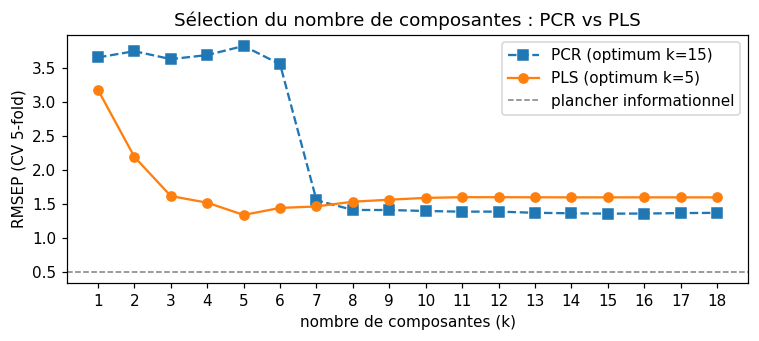

meilleur k PLS (CV) : 5 composante(s)   (PCR : 15)
RMSEP CV PLS        : 1.337   (PCR : 1.356)
RMSE test PLS       : 1.403   (PCR : 1.356, ridge : 1.483)


In [10]:
rmse_cv_pls = np.array([
    rmsep_cv(PLSRegression(n_components=k, scale=False), Xs_train, y_train).mean()
    for k in KS
])
best_k_pls = KS[np.argmin(rmse_cv_pls)]

pls = PLSRegression(n_components=best_k_pls, scale=False).fit(Xs_train, y_train)
rmse_pls_test = root_mean_squared_error(y_test, pls.predict(Xs_test).ravel())

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(KS, rmse_cv_pcr, "s--", label=f"PCR (optimum k={best_k_pcr})")
ax.plot(KS, rmse_cv_pls, "o-", label=f"PLS (optimum k={best_k_pls})")
ax.axhline(0.5, color="gray", ls="--", lw=1, label="plancher informationnel")
ax.set(xlabel="nombre de composantes (k)", ylabel="RMSEP (CV 5-fold)",
       title="Sélection du nombre de composantes : PCR vs PLS", xticks=KS)
ax.legend()
plt.tight_layout(); plt.show()

print(f"meilleur k PLS (CV) : {best_k_pls} composante(s)   (PCR : {best_k_pcr})")
print(f"RMSEP CV PLS        : {rmse_cv_pls.min():.3f}   (PCR : {rmse_cv_pcr.min():.3f})")
print(f"RMSE test PLS       : {rmse_pls_test:.3f}   (PCR : {rmse_pcr_test:.3f}, ridge : {rmse_ridge_test:.3f})")

La PLS atteint son optimum avec nettement **moins de composantes** que la PCR : sa première direction pointe directement vers la combinaison des facteurs 7-8 qui porte le signal, sans dépenser ses composantes sur les directions de grande variance. À budget de composantes égal, la PLS domine la PCR — c'est le résultat classique de la chimiométrie (Frank & Friedman, 1993).

Pourquoi ne pas conclure « PLS > PCR » trop vite ? Parce que ce classement dépend du **régime** : ici le signal est caché dans des directions de faible variance — le terrain de chasse naturel de la PLS. La section 6 construit le régime opposé et montre que l'écart se referme.

## 5. Lire les directions : scores, loadings, et le concept-phare

Comparons maintenant **les directions elles-mêmes**. Pour chaque méthode, deux quantités par composante : la part de variance de `X` qu'elle porte, et sa corrélation absolue avec `y` (sa **prédictivité**).

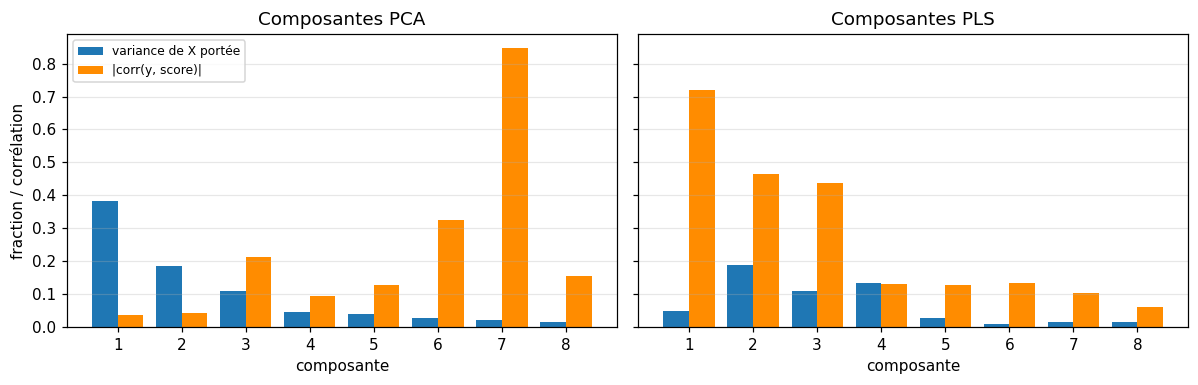

PCA : variance ['0.384', '0.186', '0.111', '0.046', '0.040', '0.028', '0.021', '0.015']
     |corr|  ['0.04 ', '0.04 ', '0.21 ', '0.09 ', '0.13 ', '0.33 ', '0.85 ', '0.16 ']
PLS : variance ['0.050', '0.188', '0.109', '0.135', '0.029', '0.011', '0.017', '0.017']
     |corr|  ['0.72 ', '0.46 ', '0.44 ', '0.13 ', '0.13 ', '0.14 ', '0.10 ', '0.06 ']


In [11]:
NC = 8   # les 8 premières composantes de chaque méthode
pls_full = PLSRegression(n_components=NC, scale=False).fit(Xs_train, y_train)
T_pca8, T_pls8 = T_pca[:, :NC], pls_full.x_scores_[:, :NC]
var_totale_X = Xs_train.var(axis=0, ddof=1).sum()

donnees = {
    "PCA": (var_expl[:NC],
            [abs(np.corrcoef(T_pca8[:, j], y_train)[0, 1]) for j in range(NC)]),
    "PLS": (T_pls8.var(axis=0, ddof=1) / var_totale_X,
            [abs(np.corrcoef(T_pls8[:, j], y_train)[0, 1]) for j in range(NC)]),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, (nom, (vares, corrs)) in zip(axes, donnees.items()):
    x = np.arange(1, NC + 1)
    ax.bar(x - 0.2, vares, width=0.4, label="variance de X portée")
    ax.bar(x + 0.2, corrs, width=0.4, color="darkorange", label="|corr(y, score)|")
    ax.set(title=f"Composantes {nom}", xlabel="composante", xticks=x)
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("fraction / corrélation")
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

for nom, (vares, corrs) in donnees.items():
    print(f"{nom} : variance {[f'{v:.3f}' for v in vares]}")
    print(f"{' ' * len(nom)}  |corr|  {[f'{c:.2f} ' for c in corrs]}")

In [12]:
# Où chaque direction met-elle son énergie ? Projection des loadings sur les blocs de variables.
bornes = np.cumsum([0] + BLOCS)
def energie_par_bloc(w):
    return [float((w[bornes[b]:bornes[b + 1]] ** 2).sum()) for b in range(L)]

pc_signal = int(np.argmax(cor_pcs)) + 1     # la composante PCA la plus corrélée à y
df_directions = pd.DataFrame(
    {
        f"PC1 (38 % de la variance)": energie_par_bloc(pca.components_[0]),
        f"PC{pc_signal} (corr(y) = {cor_pcs[pc_signal - 1]:.2f})": energie_par_bloc(pca.components_[pc_signal - 1]),
        "PLS-1 (supervisée)": energie_par_bloc(pls_full.x_weights_[:, 0]),
    },
    index=[f"bloc {b + 1} ({BLOCS[b]} var.)" for b in range(L)],
).round(3)
display(df_directions)

,PC1 (38 % de la variance),PC7 (corr(y) = 0.85),PLS-1 (supervisée)
bloc 1 (90 var.),0.965,0.062,0.067
bloc 2 (45 var.),0.029,0.029,0.034
bloc 3 (25 var.),0.001,0.029,0.134
bloc 4 (14 var.),0.003,0.021,0.023
bloc 5 (10 var.),0.001,0.053,0.020
bloc 6 (6 var.),0.001,0.099,0.006
bloc 7 (5 var.),0.000,0.421,0.427
bloc 8 (5 var.),0.001,0.287,0.289


Tout le concept-phare est dans ces deux sorties :

- **PCA, composante 1** : porte plus du tiers de la variance de `X` (38 %), corrélation avec `y` ≈ 0. Ses loadings vivent à 97 % dans le bloc 1 (90 variables) — le bloc le plus gros, **sans aucun signal**.
- **PCA, composante du signal** : ~2 % de variance, mais la corrélation avec `y` la plus élevée de toutes (0.85). Ses loadings se partagent entre les blocs 7-8.
- **PLS, composante 1** : huit fois moins de variance de `X` que PC1 (≈ 5 % contre ≈ 38 %) — et une corrélation avec `y` de 0.72 d'emblée. Ses loadings **sautent directement** sur les blocs 7-8 (72 % de l'énergie), là où vit le signal : la supervision lui a épargné de « dépenser » sa première composante sur la variance.

En pratique (spectroscopie, -omiques) : la composante de forte variance capture l'effet de matrice ou le fond technique ; le signal biologique est dans une composante mineure. Choisir ses directions au critère de variance, c'est risquer de jeter exactement ce qu'on cherche.

## 6. Verdict par régime : comparaison à protocole constant

Les classements ci-dessus sont des faits **de ce régime**. Construisons le régime opposé — même générateur, mêmes tailles, mêmes folds, mêmes graines — où le signal vit cette fois sur le **facteur 1** (le bloc dominant, 90 variables). Pour chaque régime, chaque modèle est réentraîné sur 10 graines avec hyperparamètres re-choisis par CV à chaque graine : le verdict est une moyenne ± écart-type, pas un coup de dés sur un seul split.

In [13]:
def rmse_test_par_graine(facteurs_signal, graines=range(10)):
    """RMSE test des 4 modèles sur `graines` répétitions ; hyperparamètres CV à chaque graine."""
    res = {m: [] for m in ("OLS (min-norm)", "Ridge", "PCR", "PLS")}
    for seed in graines:
        rng = np.random.default_rng(seed)
        Xtr, ytr, _ = generer_donnees(N_TRAIN, rng, facteurs_signal)
        Xte, yte, _ = generer_donnees(N_TEST, rng, facteurs_signal)
        sc = StandardScaler().fit(Xtr)
        Xs, Xt = sc.transform(Xtr), sc.transform(Xte)
        m = LinearRegression().fit(Xs, ytr)
        res["OLS (min-norm)"].append(root_mean_squared_error(yte, m.predict(Xt)))
        a = min(ALPHAS, key=lambda al: rmsep_cv(Ridge(alpha=al), Xs, ytr).mean())
        m = Ridge(alpha=a).fit(Xs, ytr)
        res["Ridge"].append(root_mean_squared_error(yte, m.predict(Xt)))
        k_p = min(KS, key=lambda k: rmsep_cv(make_pipeline(PCA(n_components=k, random_state=42), LinearRegression()), Xs, ytr).mean())
        m = make_pipeline(PCA(n_components=k_p, random_state=42), LinearRegression()).fit(Xs, ytr)
        res["PCR"].append(root_mean_squared_error(yte, m.predict(Xt)))
        k_s = min(KS, key=lambda k: rmsep_cv(PLSRegression(n_components=k, scale=False), Xs, ytr).mean())
        m = PLSRegression(n_components=k_s, scale=False).fit(Xs, ytr)
        res["PLS"].append(root_mean_squared_error(yte, m.predict(Xt).ravel()))
    return res

vA = rmse_test_par_graine((6, 7))    # régime A : signal sur les facteurs 7-8 (faible variance)
vB = rmse_test_par_graine((0,))      # régime B : signal sur le facteur 1 (forte variance)
df_verdict = pd.DataFrame({
    "A : signal sur f7-f8 (faible variance)": {m: f"{np.mean(v):.3f} ± {np.std(v):.3f}" for m, v in vA.items()},
    "B : signal sur f1 (forte variance)":     {m: f"{np.mean(v):.3f} ± {np.std(v):.3f}" for m, v in vB.items()},
})
display(df_verdict)

,A : signal sur f7-f8 (faible variance),B : signal sur f1 (forte variance)
OLS (min-norm),1.589 ± 0.122,0.672 ± 0.026
Ridge,1.554 ± 0.079,0.588 ± 0.024
PCR,1.459 ± 0.080,0.567 ± 0.023
PLS,1.455 ± 0.101,0.587 ± 0.057


**Verdict par régime** (les chiffres exacts sont dans le tableau ci-dessus) :

- **OLS min-norm est le plus mauvais des quatre dans les deux régimes** — jamais de beaucoup, mais systématiquement : la non-identifiabilité de la section 1.3 se paie en performance moyenne.
- **Régime A** (signal caché dans les faibles variances) : PCR et PLS devant (≈ 1.46), la PLS y étant la plus **parcimonieuse** (5 composantes contre 15 à la PCR) ; le ridge, pénalisé sur ses 200 coefficients, reste un cran au-dessus (≈ 1.55) ; OLS dernier (≈ 1.59).
- **Régime B** (signal aligné sur la grande variance) : la PCR prend la tête (0.57) et la PLS rejoint le ridge (0.59) — quand la première direction de variance **est** la direction prédictive, la supervision de la PLS n'apporte plus rien, et le régresseur non supervisé suffit.

La leçon n'est pas « telle méthode gagne » mais : **le choix ridge / PCR / PLS est une hypothèse sur la position du signal par rapport à la variance de X** — et la validation croisée tranche empiriquement, à condition d'un protocole constant (mêmes folds, mêmes graines, moyennes multi-graines).

### Exercice 3 : construire le régime intermédiaire

- **Objectif** : construire le régime C où PCR et PLS sont les plus proches, et expliquer pourquoi.
- **Etape 1** : appeler `rmse_test_par_graine((0, 1))` — signal sur les facteurs 1-2 (les deux blocs dominants).
- **Etape 2** : comparer la colonne obtenue aux régimes A et B ; lire où vivent les composantes optimales.
- **Indice** : plus le signal s'aligne sur les directions de grande variance, plus la PCR « rattrape » la PLS — jusqu'à la coïncidence du régime B.

In [14]:
# Exercice 3 — le régime où PCR rejoint PLS
# TODO etudiant : appeler rmse_test_par_graine((0, 1)) et comparer aux régimes A et B
resultats_ex3 = None   # TODO etudiant : dict {modele: liste de RMSE} du régime C

print("Exercice 3 a completer : verdict du régime où le signal s'aligne sur la grande variance")

Exercice 3 a completer : verdict du régime où le signal s'aligne sur la grande variance


## 7. Ce qu'il faut retenir

1. **En p >> n, le critère OLS est non identifiable** : une infinité de β exacts (démonstration constructive via le noyau de X), indiscernables sur le train, divergents en test. Le solveur choisit en silence la solution min-norm — un choix à connaître.
2. **Le ridge rend le problème identifiable** (`α||β||²`) : solution unique, α optimal intérieur choisi par CV. Sur nos données, gain de RMSE modéré mais stabilité décisive — le rôle du ridge en production (features financières corrélées du pipeline QuantConnect).
3. **La PCR réutilise l'ACP telle quelle** (pipeline `PCA` + `LinearRegression`) : réduction non supervisée ; le nombre de composantes se choisit par **CV**, jamais au seul critère de variance expliquée — qui jette le signal.
4. **La PLS construit des composantes supervisées** qui maximisent la covariance avec `y` : elle atteint le signal en moins de composantes quand il vit hors des directions de grande variance.
5. **Concept-phare** : `Var(Xu)` et `Cov(y, Xu)` ordonnent les directions différemment. Une composante de forte variance peut être muette pour `y` ; une composante mineure peut porter tout le signal. Toujours lire les deux quantités (variance expliquée vs corrélation avec `y`).
6. **Le verdict est un fait de régime** : à protocole constant (mêmes folds, mêmes graines, moyennes multi-graines), OLS dernier partout, et l'écart PCR/PLS dépend de l'alignement signal-variance — c'est la CV qui départage, pas une hiérarchie absolue.

## References

1. Hoerl, A.E. & Kennard, R.W. (1970). *Ridge Regression: Biased Estimation for Nonorthogonal Problems*. Technometrics 12(1):55-67. — L'article fondateur du ridge : la pénalité `α||β||²` rend le problème inverse bien posé en présence de colinéarité.
2. Wold, H. (1975). *Path Models with Latent Variables: The NIPALS Approach*. In Quantitative Sociology: International Perspectives on Mathematical and Statistical Model Building, Academic Press, pp. 307-357. — Origine de la PLS : composantes latentes construites en regardant `y` (algorithme NIPALS).
3. de Jong, S. (1993). *SIMPLS: An Alternative Approach to Partial Least Squares Regression*. Chemometrics and Intelligent Laboratory Systems 18(3):251-263. — Algorithme implémenté dans `sklearn.cross_decomposition.PLSRegression`.
4. Frank, I.E. & Friedman, J.H. (1993). *A Statistical View of Some Chemometrics Regression Tools*. Technometrics 35(2):109-135. — La comparaison de référence ridge / PCR / PLS : aucune ne domine universellement, tout dépend de la position du signal par rapport à la variance.
5. Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer (2e éd.), §3.4.1 (ridge), §3.5.2 (PCR), §3.5.3 (PLS). — Cadre théorique : régression sur directions latentes, lien pénalité / projection.
6. Jolliffe, I.T. (2002). *Principal Component Analysis*. Springer (2e éd.). — Choix du nombre de composantes : critères de variance **et leurs limites** en régression (cf. [2.6](2.6-Clustering-KMeans-PCA.ipynb) pour l'usage compression).
7. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research 12:2825-2830. — `Ridge`, `PCA`, `PLSRegression`, `KFold`.